# 02 Profitability Analysis & Segmentation

**Context:**
Notebook 01 established the empirical ground truth: the catalog is heavily reliant on discounting (94%+), operational failure is standard (>57% late deliveries), and top-line revenue frequently masks margin destruction.

**Purpose:**
This notebook translates those observations into actionable segmentation. I will classify products into operational quadrants, quantify the exact dollar impact of "Revenue Traps," evaluate profit concentration, and build a composite risk score to prioritize executive action.

## 1. Environment Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configure plotting style
plt.style.use('default')
sns.set_theme(style="whitegrid")

# Load ground truth master
csv_path = '../data/processed/ground_truth_master.csv'
df = pd.read_csv(csv_path)

print(f"Dataframe loaded: {df.shape[0]} rows, {df.shape[1]} columns.")

Dataframe loaded: 118 rows, 17 columns.


## 2. SKU Quadrant Classification
Classify all products into four operational quadrants based on their relationship to the catalog median for net profit percentage and late delivery risk. Revenue scale is represented by bubble size to visually identify "Revenue Traps" (large bubbles in the Cut Candidates quadrant) without distorting the operational axes.

*Note: The 46 products with fewer than 100 orders (excluded per DL-010) will be tagged as 'Excluded (Low Volume)' and omitted from this specific visual, as their delivery risk rates are statistically invalid.*

In [2]:
# Calculate Medians (excluding nulls automatically)
median_margin = df['net_profit_pct'].median()
median_risk = df['late_delivery_risk_rate'].median()

print(f"Catalog Median Margin: {median_margin:.2%}")
print(f"Catalog Median Delivery Risk: {median_risk:.2%}")

# Define Quadrant Logic
def assign_quadrant(row):
    if pd.isna(row['late_delivery_risk_rate']):
        return 'Excluded (Low Volume)'
        
    if row['net_profit_pct'] >= median_margin and row['late_delivery_risk_rate'] < median_risk:
        return 'Cash Generators'
    elif row['net_profit_pct'] >= median_margin and row['late_delivery_risk_rate'] >= median_risk:
        return 'Operational Risks'
    elif row['net_profit_pct'] < median_margin and row['late_delivery_risk_rate'] < median_risk:
        return 'Underperformers'
    elif row['net_profit_pct'] < median_margin and row['late_delivery_risk_rate'] >= median_risk:
        return 'Cut Candidates'
    else:
        return 'Unknown'

# Apply classification
df['quadrant'] = df.apply(assign_quadrant, axis=1)

# Summary counts
print("\n--- QUADRANT DISTRIBUTION ---")
print(df['quadrant'].value_counts())

Catalog Median Margin: 11.11%
Catalog Median Delivery Risk: 57.75%

--- QUADRANT DISTRIBUTION ---
quadrant
Operational Risks    32
Underperformers      31
Cut Candidates       28
Cash Generators      27
Name: count, dtype: int64


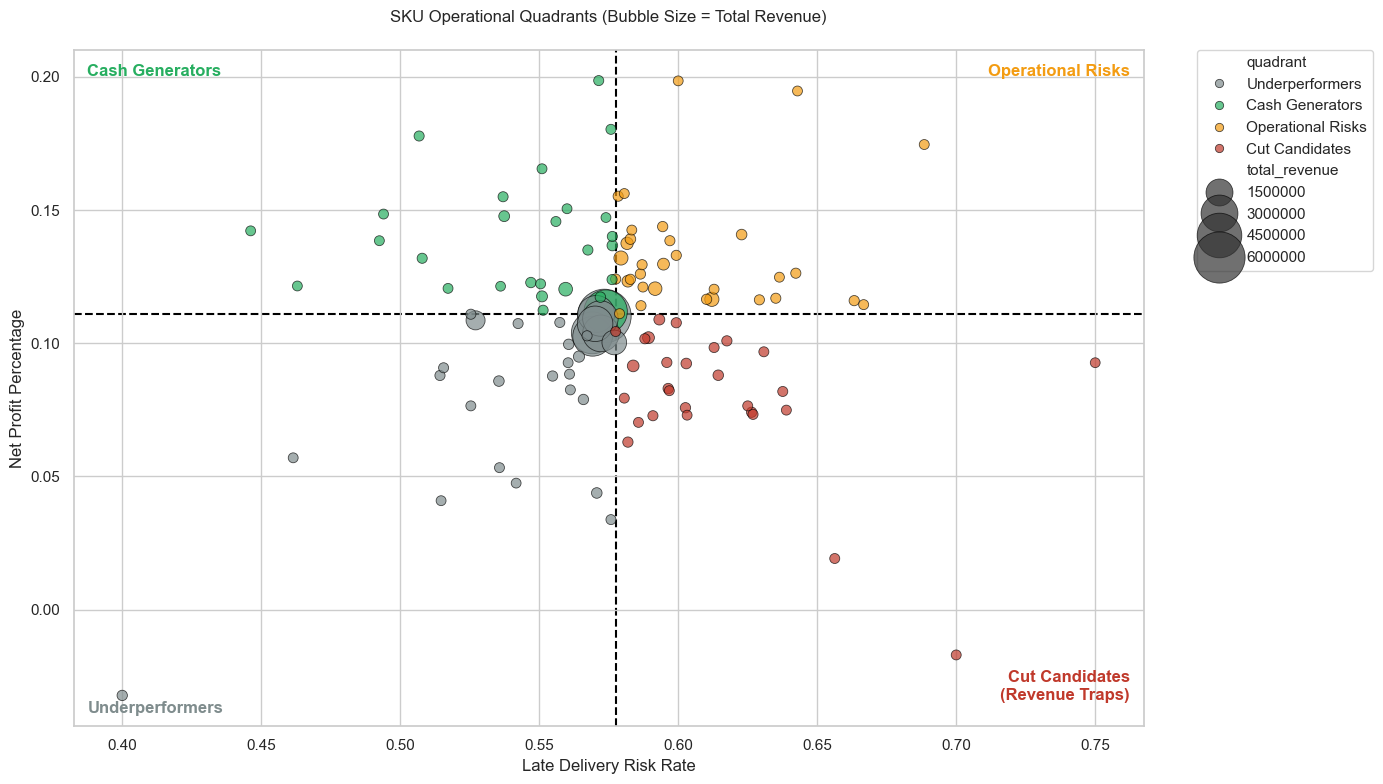

In [3]:
# Filter out excluded items for the plot (safety step)
plot_df = df[df['quadrant'] != 'Excluded (Low Volume)']

plt.figure(figsize=(14, 8))

# Create bubble chart
sns.scatterplot(
    data=plot_df, 
    x='late_delivery_risk_rate', 
    y='net_profit_pct', 
    size='total_revenue', 
    sizes=(50, 1500), 
    hue='quadrant',
    palette={
        'Cash Generators': '#27ae60', 
        'Operational Risks': '#f39c12', 
        'Underperformers': '#7f8c8d', 
        'Cut Candidates': '#c0392b'
    },
    alpha=0.7,
    edgecolor='black'
)

# Add median threshold lines
plt.axvline(median_risk, color='black', linestyle='--', linewidth=1.5, zorder=0)
plt.axhline(median_margin, color='black', linestyle='--', linewidth=1.5, zorder=0)

# Quadrant Labels (dynamically positioned near corners)
x_min, x_max = plt.xlim()
y_min, y_max = plt.ylim()

plt.text(x_min + 0.005, y_max - 0.01, 'Cash Generators', color='#27ae60', fontsize=12, fontweight='bold', ha='left')
plt.text(x_max - 0.005, y_max - 0.01, 'Operational Risks', color='#f39c12', fontsize=12, fontweight='bold', ha='right')
plt.text(x_min + 0.005, y_min + 0.005, 'Underperformers', color='#7f8c8d', fontsize=12, fontweight='bold', ha='left')
plt.text(x_max - 0.005, y_min + 0.01, 'Cut Candidates\n(Revenue Traps)', color='#c0392b', fontsize=12, fontweight='bold', ha='right')

plt.title('SKU Operational Quadrants (Bubble Size = Total Revenue)', pad=20)
plt.xlabel('Late Delivery Risk Rate')
plt.ylabel('Net Profit Percentage')

# Adjust legend
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)
plt.tight_layout()
plt.show()

**Business Interpretation:**
* **The Scale Illusion:** The largest bubbles (top revenue generators) are clustered tightly around the crosshairs of the medians. The business has not scaled its most efficient or reliable products; it has simply pumped massive volume into profoundly average SKUs. 
* **The "Cut Candidates" Bleed:** There are 28 products sitting in the bottom-right quadrant (below median margin, above median delivery risk). These products combine weak unit economics with active operational failure. 
* **Balanced Distribution:** The catalog splits almost perfectly evenly across the four quadrants. This confirms my decision to use medians (DL-011) was correct, it effectively neutralized the severe right-skew of the volume outliers and established a realistic internal baseline for performance.

## 3. Revenue Trap Deep Dive
Isolate the "Cut Candidates" quadrant to quantify the total financial liability of products that fail on both margin and delivery risk. Identify the specific high-revenue offenders masquerading as top-sellers.

In [4]:
# Isolate Cut Candidates
cut_candidates = df[df['quadrant'] == 'Cut Candidates'].copy()

# Quantify the quadrant's total impact
total_trap_revenue = cut_candidates['total_revenue'].sum()
total_trap_profit = cut_candidates['total_profit'].sum()
catalog_total_revenue = df['total_revenue'].sum()

print("CUT CANDIDATES (REVENUE TRAPS) SUMMARY")
print(f"Total Products: {len(cut_candidates)}")
print(f"Total Revenue Tied Up: ${total_trap_revenue:,.2f} ({(total_trap_revenue / catalog_total_revenue):.1%} of Catalog)")
print(f"Total Profit Generated: ${total_trap_profit:,.2f}")
print(f"Aggregate Net Margin of this Quadrant: {(total_trap_profit / total_trap_revenue):.2%}\n")

# Display the worst offenders (Highest Revenue in the Cut quadrant)
worst_offenders = cut_candidates.sort_values(by='total_revenue', ascending=False).head(10)

print("TOP 10 REVENUE TRAPS (Ranked by Top-Line Scale):")
display_cols = ['product_card_id', 'product_name', 'total_revenue', 'net_profit_pct', 'late_delivery_risk_rate', 'revenue_rank', 'profit_rank', 'rank_divergence']
print(worst_offenders[display_cols].to_string(index=False))

CUT CANDIDATES (REVENUE TRAPS) SUMMARY
Total Products: 28
Total Revenue Tied Up: $763,442.09 (2.2% of Catalog)
Total Profit Generated: $67,302.84
Aggregate Net Margin of this Quadrant: 8.82%

TOP 10 REVENUE TRAPS (Ranked by Top-Line Scale):
 product_card_id                                  product_name  total_revenue  net_profit_pct  late_delivery_risk_rate  revenue_rank  profit_rank  rank_divergence
            1360                                  Smart watch       110124.00          0.1021                   0.5893            16           18               -2
            1356                                 First aid kit      101391.84          0.0915                   0.5838            19           19                0
             728      LIJA Women's Eyelet Sleeveless Golf Polo       58695.00          0.1089                   0.5932            22           23               -1
             249 Under Armour Women's Micro G Skulpt Running S       44195.88          0.0924              

**Business Interpretation:**
* **The Asymmetry of Bloat:** The "Cut Candidates" quadrant contains 24% of the physical catalog (28 SKUs), but they generate only 2.2% of total revenue. The business is burning massive operational bandwidth managing inventory, handling late delivery complaints, and subsidizing discounts for a microscopic fraction of its top line.
* **Low-Risk Amputation:** Because these products are financially insignificant at the macro level, the founder can aggressively cut them. Eliminating nearly a quarter of the catalog (including failing SKUs from major brands like Under Armour and Adidas) would instantly streamline supply chain operations without threatening the core revenue stream.
* **The "Zombie SKU" Reality:** These aren't massive commercial traps holding the business hostage; they are zombie SKUs. They generate enough volume to look active on a spreadsheet, but they fail financially (8.8% aggregate margin) and operationally (>58% delivery risk).

## 4. Profit Concentration Analysis
Evaluate catalog dependency by calculating the cumulative profit curve. If the business is heavily concentrated, a massive portion of the catalog can be restructured without impacting the bottom line.

PROFIT CONCENTRATION
Products required to generate 80% of total profit: 8 out of 118 (6.8%)


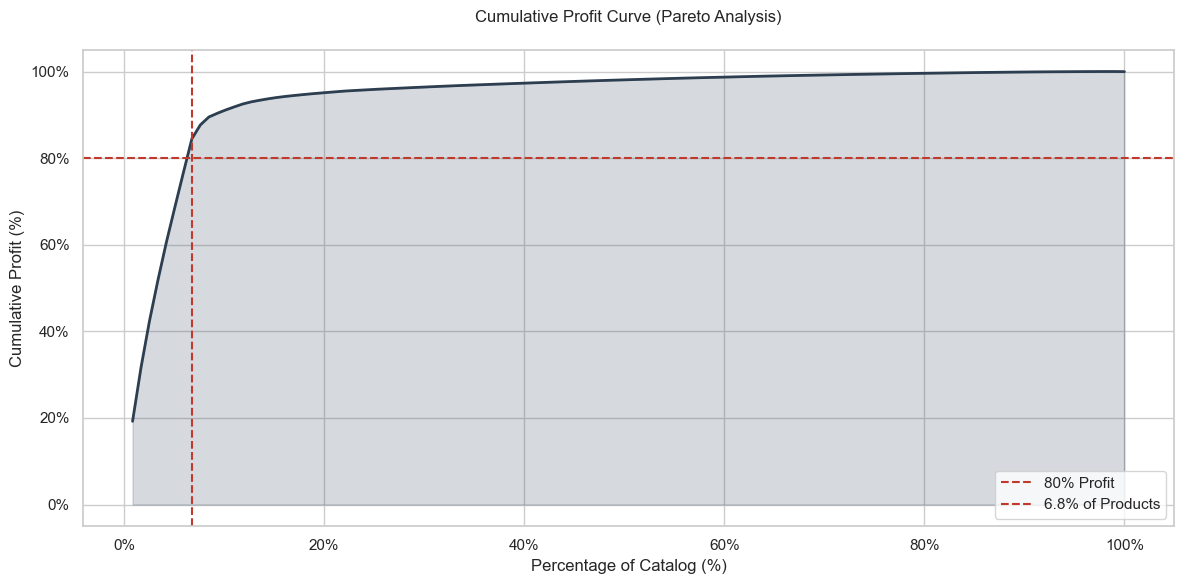

In [5]:
# Sort products by total profit descending
profit_df = df.sort_values(by='total_profit', ascending=False).copy()

# Calculate cumulative percentages
profit_df['cumulative_profit'] = profit_df['total_profit'].cumsum()
profit_df['cumulative_profit_pct'] = profit_df['cumulative_profit'] / profit_df['total_profit'].sum()
profit_df['product_count'] = np.arange(1, len(profit_df) + 1)
profit_df['product_count_pct'] = profit_df['product_count'] / len(profit_df)

# Find the 80% threshold
threshold_80 = profit_df[profit_df['cumulative_profit_pct'] >= 0.8].iloc[0]
products_for_80_pct = threshold_80['product_count']
pct_for_80_pct = threshold_80['product_count_pct']

print("PROFIT CONCENTRATION")
print(f"Products required to generate 80% of total profit: {products_for_80_pct} out of {len(df)} ({pct_for_80_pct:.1%})")

# Plot the cumulative profit curve
plt.figure(figsize=(12, 6))
sns.lineplot(data=profit_df, x='product_count_pct', y='cumulative_profit_pct', color='#2c3e50', linewidth=2)

# Fill the area under the curve
plt.fill_between(profit_df['product_count_pct'], profit_df['cumulative_profit_pct'], color='#34495e', alpha=0.2)

# Reference lines
plt.axhline(0.8, color='#c0392b', linestyle='--', linewidth=1.5, label='80% Profit')
plt.axvline(pct_for_80_pct, color='#c0392b', linestyle='--', linewidth=1.5, label=f'{pct_for_80_pct:.1%} of Products')

# Formatting
plt.title('Cumulative Profit Curve (Pareto Analysis)', pad=20)
plt.xlabel('Percentage of Catalog (%)')
plt.ylabel('Cumulative Profit (%)')
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
plt.legend(loc='lower right')

plt.tight_layout()
plt.show()

**Business Interpretation:**
* **Extreme Profit Concentration:** The business does not just follow the Pareto (80/20) principle; it severely exceeds it. A mere 6.8% of the catalog (just 8 products) generates 80% of the total profit. The profit curve spikes instantly and flatlines almost immediately.
* **The Illusion of a Catalog:** The remaining 110 products are fighting over the last 20% of the margin, yet they consume the vast majority of supply chain bandwidth, inventory capital, and customer service resources. The catalog is mostly operational noise.
* **Structural Fragility:** While this concentration proves the business can safely amputate its bottom quartile, it also exposes a critical single-point-of-failure. If logistics or supplier pricing fails for any of those 8 core SKUs, the business's profitability collapses entirely.

## 5. Discount Dependency vs. Quadrant Segmentation
I established in EDA that discounting is a systemic constant, but here I test if the *severity* of that discounting dictates quadrant placement. Are the failing products failing specifically because they require heavier promotional subsidies to move?

DISCOUNT SEVERITY BY QUADRANT (Product Count)
discount_severity  Baseline (<90%)  High (90-95%)  Severe (>95%)
quadrant                                                        
Cash Generators                  0             19              8
Cut Candidates                   0             19              9
Operational Risks                1             22              9
Underperformers                  1             21              9


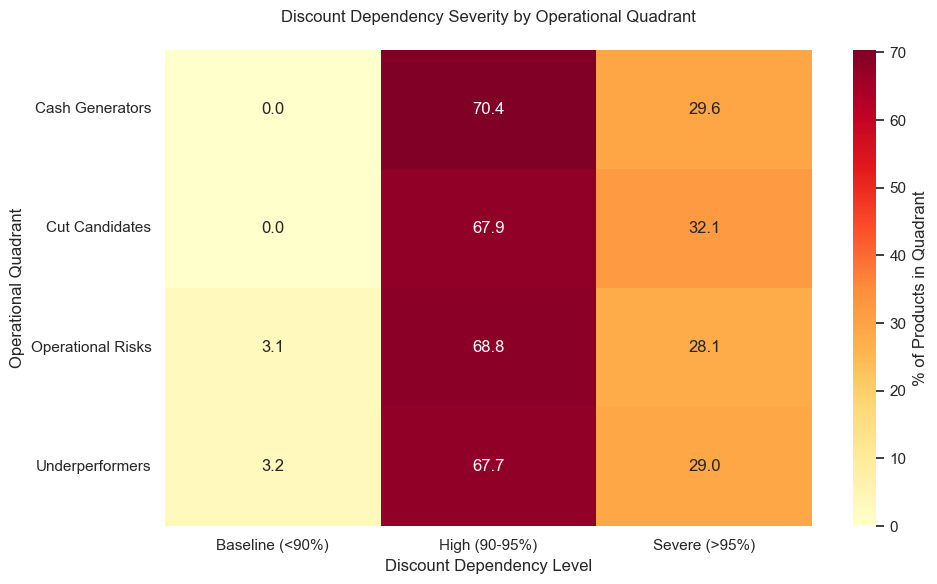

In [7]:
# Create discount dependency severity buckets
# I know the baseline is high, so I split at the 90% and 95% marks to isolate extreme behavior
bins = [-1, 90, 95, 100]
labels = ['Baseline (<90%)', 'High (90-95%)', 'Severe (>95%)']

# Apply to a working copy to avoid altering the main df structure before scoring
segment_df = df.copy()
segment_df['discount_severity'] = pd.cut(segment_df['discount_dependency_rate'], bins=bins, labels=labels)

# Filter out the excluded low-volume items for accurate proportional mapping (again safety step)
segment_df = segment_df[segment_df['quadrant'] != 'Excluded (Low Volume)']

# Cross-tabulate and calculate percentages within each quadrant
crosstab_raw = pd.crosstab(segment_df['quadrant'], segment_df['discount_severity'])
crosstab_pct = crosstab_raw.div(crosstab_raw.sum(axis=1), axis=0) * 100

print("DISCOUNT SEVERITY BY QUADRANT (Product Count)")
print(crosstab_raw)

# Visualise as a heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(crosstab_pct, annot=True, fmt=".1f", cmap="YlOrRd", cbar_kws={'label': '% of Products in Quadrant'})
plt.title('Discount Dependency Severity by Operational Quadrant', pad=20)
plt.ylabel('Operational Quadrant')
plt.xlabel('Discount Dependency Level')
plt.tight_layout()
plt.show()

**Business Interpretation:**
* **The Universal Baseline:** The heatmap proves that severe discounting is not the mechanism driving products into the "Cut Candidates" quadrant. The distribution is nearly identical across all four quadrants. Even the "Cash Generators" rely on discounts for >90% of their transactions. 
* **A Structural Cost, Not a Variable Tactic:** Because discounting is uniformly applied across both successful and failing products, it must be viewed as a fixed structural cost of the business rather than a promotional lever. 
* **The True Failure Mechanism:** Since discounting does not differentiate a Cash Generator from a Revenue Trap, the failure of the Cut Candidates must stem entirely from their base unit economics (high COGS) or severe operational friction (expedited shipping penalties from constant late deliveries) yet not confirmed.